<a href="https://colab.research.google.com/github/ngtrmquang/goodreads-data-project/blob/linh/EDA_user_rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. **Importing required libraries**

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

2. **Reading Dataset**

In [162]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/mart_user_ratings.parquet"
df = pd.read_parquet(path)
print(df.head(5))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                            user_id   book_id                   book_title  \
0  733d1a864a29c2a337e4c4862a865dcb  18071590                Me Before You   
1  8331156ffec5f492e4a10a85f4aaac85    298230                   Agnes Grey   
2  73fe252243e1a82acc7b407f12114d91     73070             It Had to Be You   
3  b0579d39685bf9ea52d519ba28b6a1d2   6068551                       Shiver   
4  20bfb3356b796552cdbb9115872e7e50     17125  Odin den' Ivana Denisovicha   

   user_rating                        book_author_names  book_average_rating  \
0            3               [Emo Malmberg, Jojo Moyes]                 4.27   
1            3           [Angeline Goreau, Anne Bronte]                 3.65   
2            0               [Susan Elizabeth Phillips]                 4.04   
3            0                      [Maggie Stiefvater]                 3.78   
4 

3. **Analyzing the Data**

In [163]:
df.shape

(5000000, 12)

In [164]:
df.columns

Index(['user_id', 'book_id', 'book_title', 'user_rating', 'book_author_names',
       'book_average_rating', 'book_publication_year', 'book_genre_1',
       'book_genre_2', 'book_genre_3', 'book_genre_4', 'book_genre_5'],
      dtype='object')

In [165]:
df.dtypes


,0
user_id,object
book_id,int32
book_title,object
user_rating,int32
book_author_names,object
book_average_rating,float32
book_publication_year,float64
book_genre_1,object
book_genre_2,object
book_genre_3,object


4. **Checking missing values**

In [166]:
df.isna().sum()

,0
user_id,0
book_id,0
book_title,376
user_rating,0
book_author_names,0
book_average_rating,376
book_publication_year,796623
book_genre_1,44258
book_genre_2,326605
book_genre_3,734689


5. **Handling missing values**

In [167]:
df = df.dropna(subset = ['book_title', 'book_average_rating'])

df['book_publication_year'] = df['book_publication_year'].isna().astype(int)
df['book_publication_year'] = df['book_publication_year'].fillna('Unknown')

In [168]:
genre_cols = [
    'book_genre_1',
    'book_genre_2',
    'book_genre_3',
    'book_genre_4',
    'book_genre_5'
]

df[genre_cols] = df[genre_cols].fillna('Unknown')

6. **Checking outliers**

In [169]:
numeric_cols = df.select_dtypes(include='number').columns

print(numeric_cols)

Index(['book_id', 'user_rating', 'book_average_rating',
       'book_publication_year'],
      dtype='object')


In [170]:
print(df['user_rating'].value_counts().sort_index())

user_rating
0    2655598
1      44217
2     141439
3     538354
4     867306
5     752710
Name: count, dtype: int64


In [171]:
invalid_rating = df[
    (df['user_rating'] < 0 ) |
    (df['user_rating'] > 5)
]

print("Invalid ratings:", len(invalid_rating))

Invalid ratings: 0


In [172]:
Q1 = df['book_average_rating'].quantile(0.25)
Q3 = df['book_average_rating'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['book_average_rating'] < lower) |
    (df['book_average_rating'] > upper)
]

print("Number of outliers:", len(outliers))
print("Lower bound:", lower)
print("Upper bound:", upper)

Number of outliers: 93385
Lower bound: 3.2150001525878906
Upper bound: 4.694999694824219


7. **Descriptive Analysis**

a. Univariate

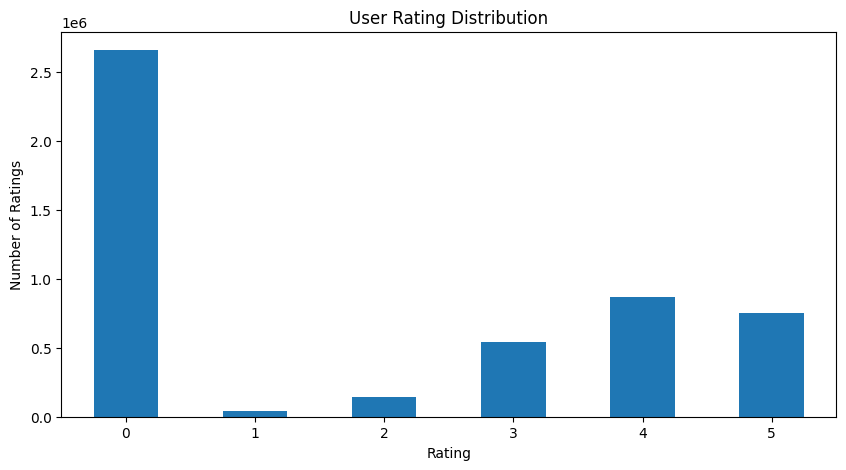

In [173]:
# User rating
df['user_rating'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10,5)
)

plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.title('User Rating Distribution')
plt.xticks(rotation=0)

plt.show()

Most users give 0 rating

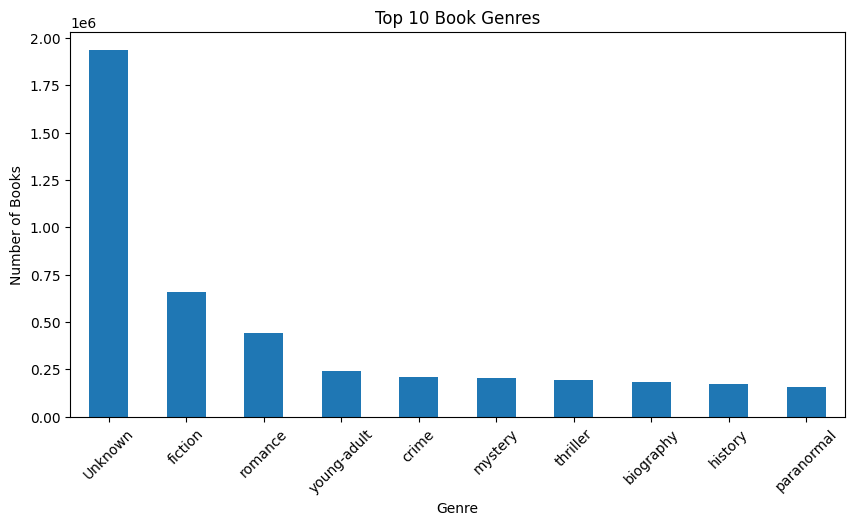

In [174]:
# Book genre 5
df['book_genre_5'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.xlabel('Genre')
plt.ylabel('Number of Books')
plt.title('Top 10 Book Genres')

plt.xticks(rotation=45)
plt.show()

The 2nd most popular genre is 'Fiction'

b. Bivariate and Multivariate

In [175]:
genre_rating = df.groupby(
    'book_genre_1'
)['user_rating'].agg(
    ['count', 'mean']
).sort_values(
    'count',
    ascending=False
)

genre_rating.head(20)

,count,mean
book_genre_1,,
fiction,1295337,1.835982
romance,779964,1.717197
non-fiction,547664,1.457908
paranormal,485274,2.007736
fantasy,463487,1.947809
young-adult,338483,1.696153
children,174100,2.765974
crime,149452,1.953798
mystery,143739,1.912445


'Children' genre in 'book_genre_1' has the highest mean rating (at 2.765974)

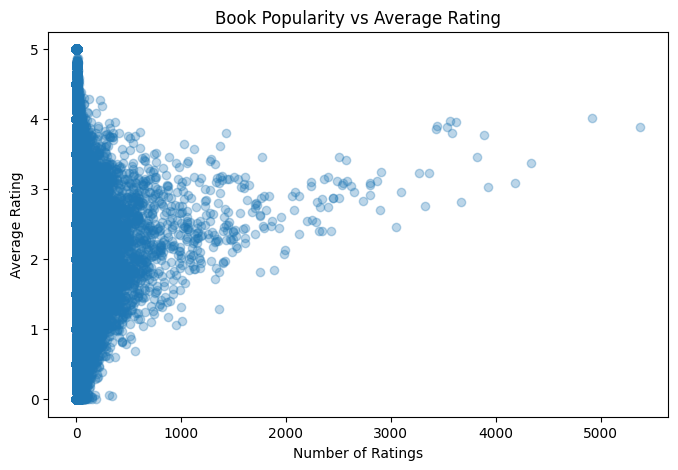

In [176]:
book_stats = df.groupby('book_id').agg(
    rating_count=('user_rating', 'count'),
    average_rating=('user_rating', 'mean')
)

plt.figure(figsize=(8,5))

plt.scatter(
    book_stats['rating_count'],
    book_stats['average_rating'],
    alpha=0.3
)

plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.title('Book Popularity vs Average Rating')

plt.show()

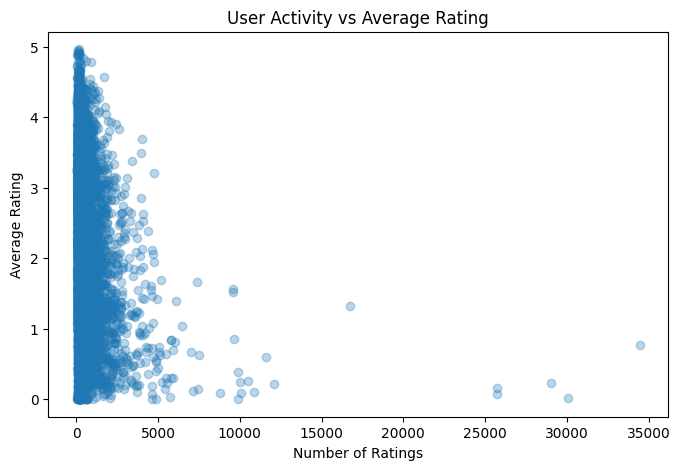

In [182]:
user_stats = df.groupby('user_id').agg(
    rating_count=('user_rating', 'count'),
    average_rating=('user_rating', 'mean')
)

plt.figure(figsize=(8,5))

plt.scatter(
    user_stats['rating_count'],
    user_stats['average_rating'],
    alpha=0.3
)

plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.title('User Activity vs Average Rating')

plt.show()

Non-active users have higher average ratings

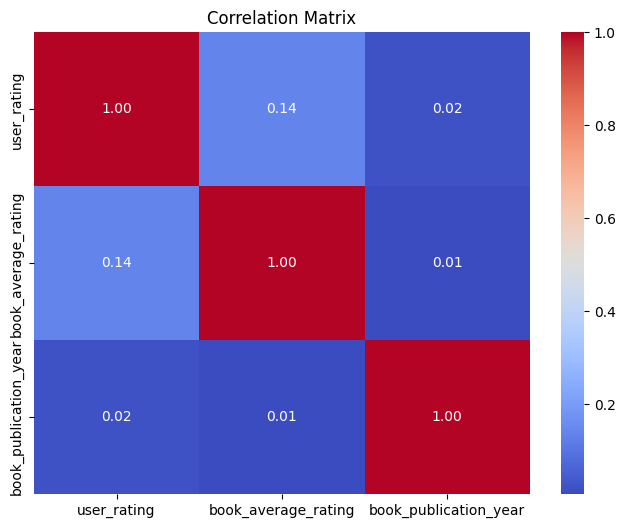

In [185]:
df[
    ['user_rating',
     'book_average_rating',
     'book_publication_year']
].corr()

numeric_cols = [
    'user_rating',
    'book_average_rating',
    'book_publication_year'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()